In [1]:
#| default_exp algorithms

In [2]:
#| export


In [3]:
#| hide

import matplotlib.pyplot as plt
import meshplot

# used only by the test/demo cells below, not by the exported module
import numpy as np
import igl

from triangulax.triangular import TriMesh


In [4]:
#| export

import jax
import jax.numpy as jnp

In [5]:
#| export

from jaxtyping import Float, Bool, Int

In [6]:
#| export

from triangulax import trigonometry as trig
from triangulax import mesh as msh
from triangulax import adjacency as adj
from triangulax import geometry as geom
from triangulax import topology as topo

In [7]:
#| hide

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update('jax_log_compiles', False) # use this to log JAX JIT compilations.

In [8]:
#| hide

import jaxtyping


In [9]:
#| hide

%load_ext jaxtyping 
%jaxtyping.typechecker beartype.beartype

# enables type checking. does not work for some cells (vmapping and loading/saving). For those, %unload_ext jaxtyping 


## `algorithms`: Geometry-processing algorithms

This notebook defines geometry processing algorithms building on the geometric primitives defined in the preceding modules.


### Mesh and point-to-point alignment

[Kabsch alignment](https://en.wikipedia.org/wiki/Kabsch_algorithm) finds the optimal (proper) rotation and translation between two matched sets of points. Here, we provide a JAX-compatible version.

In [10]:
#| export

def kabsch_align(v: Float[jax.Array, "n_vertices dim"], v_ref: Float[jax.Array, "n_vertices dim"]
                 ) -> tuple[Float[jax.Array, "n_vertices dim"],
                            Float[jax.Array, "dim dim"],
                            Float[jax.Array, " dim"]]:
    """Optimally rotate/translate v onto v_ref (differentiable Kabsch algorithm).

    The resulting rotation R is proper (det(R) = 1), so no reflections are allowed.
    Works in any dimension, and is compatible with jax.jit and jax.grad.
    The convention is ``aligned == v @ R + d``.

    Parameters
    ----------
    v : Float[jax.Array, "n_vertices dim"]
        vertices to be aligned
    v_ref : Float[jax.Array, "n_vertices dim"]
        reference vertices

    Returns
    -------
    aligned : Float[jax.Array, "n_vertices dim"]
        v optimally aligned to v_ref
    R : Float[jax.Array, "dim dim"]
        Optimal rotation matrix
    d : Float[jax.Array, "dim"]
        Optimal translation vector
    """
    d1 = v.mean(axis=0)
    d2 = v_ref.mean(axis=0)
    vc = v - d1
    rc = v_ref - d2
    U, _, Vt = jnp.linalg.svd(vc.T @ rc, full_matrices=False)  # full_matrices=False: full SVD has no JVP rule
    sign = jnp.sign(jnp.linalg.det(U @ Vt))
    # flip the last singular direction if needed, so that det(R) = +1 in any dimension
    R = (U * jnp.ones(U.shape[-1]).at[-1].set(sign)) @ Vt
    aligned = vc @ R + d2
    d = -d1 @ R + d2  # note: shadows the reflection sign above
    return aligned, R, d

### Smoothing and remeshing

Two operations to improve mesh quality without altering surface shape:
1. Tangential smoothing moves mesh vertices to the area-weighted average of the neighbors, along the tangential direction only
2. Delaunay flips improve triangle aspect ratio by edge flips. This modifies the mesh topology, but leaves the vertex set unchanged.

In [11]:
# Load test mesh
mesh = TriMesh.read_obj("../test_meshes/disk.obj", dim=2)
hemesh = msh.HeMesh.from_triangles(mesh.vertices.shape[0], mesh.faces)
vertices = mesh.vertices

  o flat_tri_ecmc


### Mesh quality assessment

Functions to evaluate triangle mesh quality: per-face maximum corner angle, summary statistics, and a human-readable quality report.

In [12]:
#| export

def get_face_angles(vertices: Float[jax.Array, "n_vertices dim"],
                        hemesh: msh.HeMesh) -> Float[jax.Array, "n_faces 3"]:
    """Get the three corner angles of every face (radians).

    Uses the half-edge corner angles. Angles within a face sum to pi.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh connectivity.

    Returns
    -------
    Float[Array, "n_faces 3"]
        The three interior angles of each triangle.
    """
    angles = geom.get_corner_angles(vertices, hemesh)
    fi = hemesh.face_incident
    face_angles = jnp.stack([angles[fi], angles[hemesh.nxt[fi]], angles[hemesh.prv[fi]]], axis=-1)
    return face_angles

In [13]:
# Test get_face_max_angles
angles = get_face_angles(vertices, hemesh)
max_angles = jnp.max(angles, axis=-1)
print(f"max angles: min={jnp.rad2deg(max_angles.min()):.1f}°,max={jnp.rad2deg(max_angles.max()):.1f}°, mean={jnp.rad2deg(max_angles.mean()):.1f}°")
assert max_angles.shape == (hemesh.n_faces,)
assert jnp.all(max_angles >= jnp.pi / 3 - 1e-6)  # max angle >= 60° always

max angles: min=60.4°,max=106.6°, mean=75.0°


In [14]:
#| export

def get_mesh_quality_stats(vertices: Float[jax.Array, "n_vertices dim"],
                           hemesh: msh.HeMesh, degenerate_angle: float = 5.0, 
                           digits: int = 5) -> dict:
    """Compute mesh quality statistics.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh connectivity.
    degenerate_angle : float
        Threshold (degrees) for a triangle to be considered degenerate.
        (I.e. if max angle > pi-threshold or min angle < threshold.)
    digits : int
        Number of decimal digits to round the statistics to.
    Returns
    -------
    dict
        Dictionary with keys: 'areas_min', 'areas_max', 'areas_cv',
        'max_angle', 'min_angle', 'angles_std',
        'n_degenerate', 'n_total_faces'.
    """
    areas = geom.get_triangle_areas(vertices, hemesh)
    angles = get_face_angles(vertices, hemesh)
    is_degenerate = ( (jnp.rad2deg(jnp.max(angles, axis=-1)) > (180.0 - degenerate_angle))
                     | (jnp.rad2deg(jnp.min(angles, axis=-1)) < degenerate_angle) )

    return {
        'areas_min': round(float(areas.min()), digits),
        'areas_max': round(float(areas.max()), digits),
        'areas_cv': round(float(trig.safe_divide(areas.std(), areas.mean())), digits),
        'max_angle': round(float(jnp.rad2deg(angles.max())), digits),
        'min_angle': round(float(jnp.rad2deg(angles.min())), digits),
        'angles_std': round(float(jnp.rad2deg(angles.std())), digits),
        'n_degenerate': int(is_degenerate.sum()),
        'n_total_faces': int(hemesh.n_faces),
    }

In [15]:
# Test mesh quality report
stats = get_mesh_quality_stats(vertices, hemesh)
stats

{'areas_min': 0.00615,
 'areas_max': 0.0218,
 'areas_cv': 0.18788,
 'max_angle': 106.60695,
 'min_angle': 31.15478,
 'angles_std': 13.73223,
 'n_degenerate': 0,
 'n_total_faces': 224}

### Delaunay flipping

Flip edges to improve triangle quality based on the Delaunay criterion: for each interior edge, the sum of the two opposite angles should not exceed π. Based on [GeometryCentral: Extrinsic Delaunay Flipping](https://geometry-central.net/surface/algorithms/remeshing/#extrinsic-delaunay-flipping).

Note: extrinsic flipping is *not* guaranteed to produce a fully Delaunay mesh, but generally improves quality in practice.

In [16]:
#| export

def is_locally_delaunay(vertices: Float[jax.Array, "n_vertices dim"],
                        hemesh: msh.HeMesh) -> Bool[jax.Array, " n_hes"]:
    """Check the local Delaunay condition for each edge.

    An interior edge is locally Delaunay when the sum of the two
    opposite angles does not exceed π.  Boundary edges are always
    considered Delaunay.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh connectivity.

    Returns
    -------
    Bool[Array, "n_hes"]
        True where the edge satisfies the Delaunay condition.
    """
    angles = geom.get_corner_angles(vertices, hemesh)
    angle_sum = angles + angles[hemesh.twin]
    return hemesh.is_bdry_edge | (angle_sum <= jnp.pi + 1e-10)

In [17]:
# Test is_locally_delaunay
delaunay = is_locally_delaunay(vertices, hemesh)
print(f"Non-Delaunay edges: {(~delaunay & hemesh.is_unique & ~hemesh.is_bdry_edge).sum()}")
assert delaunay.shape == (hemesh.n_hes,)
assert jnp.all(delaunay[hemesh.is_bdry_edge])  # boundary edges are always Delaunay

Non-Delaunay edges: 4


In [32]:
#| export

def fix_delaunay(vertices: Float[jax.Array, "n_vertices dim"],
                 hemesh: msh.HeMesh,
                 max_iters: int = 2, max_flips: int = 10) -> tuple[msh.HeMesh, Int[jax.Array, ""]]:
    """Flip non-Delaunay edges iteratively until convergence.

    Each iteration identifies non-Delaunay interior edges and flips them
    using ``topology.flip_by_score``.  Stops when no more flips are needed
    or ``max_iters`` is reached.

    Important: when JIT-compiling, use jax.jit with static_argnames=['max_iters', 'max_flips'].

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions (unchanged by flips).
    hemesh : HeMesh
        Half-edge mesh connectivity.
    max_iters : int
        Maximum number of sweep iterations.
    max_flips : int
        Maximum number of flips at each iteration.
    Returns
    -------
    hemesh_new : HeMesh
        Updated half-edge mesh with improved Delaunay quality.
    n_flips : int
        Total number of edges flipped.
    """
    def cond_fun(state):
        hemesh_s, n_flips, i, did_flip = state
        return (i < max_iters) & did_flip

    def body_fun(state):
        hemesh_s, n_flips, i, _ = state
        delaunay_score = geom.get_cotan_weights_per_edge(vertices, hemesh_s)
        hemesh_s, did_flip = topo.flip_by_score(hemesh_s, edge_score=delaunay_score,
                                                threshold=0.0, max_flips=max_flips)
        n_new = did_flip.sum() // 2
        return (hemesh_s, n_flips + n_new, i + 1, n_new > 0)

    init_state = (hemesh, jnp.array(0), jnp.array(0), jnp.array(True))
    hemesh_out, n_flips, _, _ = jax.lax.while_loop(cond_fun, body_fun, init_state)
    return hemesh_out, n_flips

In [33]:
#| hide

# Test fix_delaunay at several noise levels: the result must be a VALID mesh and
# strictly closer to Delaunay. (At noise >= ~0.06 this used to silently produce a
# non-manifold mesh, and is_locally_delaunay on a corrupt mesh returns garbage.)
# Note flips alone cannot always reach a fully Delaunay triangulation on a fixed
# vertex set: a flip that would duplicate an existing edge is correctly refused.

for noise_level in [0.025, 0.06, 0.10]:
    key = jax.random.PRNGKey(42)
    noisy_vertices = vertices + noise_level * jax.random.normal(key, shape=vertices.shape)

    interior = hemesh.is_unique & ~hemesh.is_bdry_edge
    n_bad_before = (~is_locally_delaunay(noisy_vertices, hemesh) & interior).sum()
    hemesh_fixed, n_flips = fix_delaunay(noisy_vertices, hemesh, max_iters=30)
    n_bad_after = (~is_locally_delaunay(noisy_vertices, hemesh_fixed)
                   & hemesh_fixed.is_unique & ~hemesh_fixed.is_bdry_edge).sum()
    print(f"noise={noise_level}: non-Delaunay {n_bad_before} -> {n_bad_after}, flips={n_flips}")

    assert msh.test_mesh_validity(hemesh_fixed)       # flips must not corrupt connectivity
    assert n_bad_after < n_bad_before                 # and must make progress
    assert hemesh_fixed.n_items == hemesh.n_items     # flips preserve mesh size

assert n_bad_after == 0 or noise_level > 0.025        # low noise is fully fixable


noise=0.025: non-Delaunay 15 -> 0, flips=15
noise=0.06: non-Delaunay 56 -> 1, flips=73
noise=0.1: non-Delaunay 68 -> 8, flips=114


(np.float64(-1.1095560709185655),
 np.float64(1.1367757897682687),
 np.float64(-1.1738700928886574),
 np.float64(1.2391634534641573))

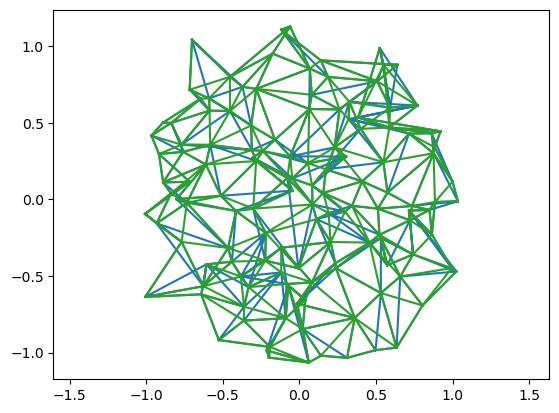

In [34]:
#| hide

plt.triplot(noisy_vertices[:, 0], noisy_vertices[:, 1], hemesh.faces)
plt.triplot(noisy_vertices[:, 0], noisy_vertices[:, 1], hemesh_fixed.faces)
plt.axis('equal')


### Tangential vertex smoothing

Vertex smoothing moves each vertex towards the average of its neighborhood. `triangulax` implements **laplacian smoothing**, which moves vertices towards the average of neighboring vertex positions.

In either case, for 3D meshes the displacement is projected tangentially (normal component removed). Boundary conditions can be `'fixed'` (boundary vertices immobile) or `'free'`.

Based on: [GeometryCentral: Tangential Vertex Smoothing](https://geometry-central.net/surface/algorithms/remeshing/#tangential-vertex-smoothing).

In [25]:
#| export

def smooth_vertices_laplacian(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh,
                              step_size: float = 1.0, bc: str = 'fixed') -> Float[jax.Array, "n_vertices dim"]:
    """One step of tangential Laplacian vertex smoothing.

    Moves each vertex towards the mean position of its neighbours.
    For 3D meshes, the displacement is projected onto the tangent plane.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh connectivity.
    step_size : float
        Fraction of displacement to apply (1 = full step).
    bc : str
        Boundary condition: 'fixed' freezes boundary vertices,
        'free' allows them to move, and 'slide' allows them to
        move only tangentially along the boundary.

    Returns
    -------
    Float[Array, "n_vertices dim"]
        Updated vertex positions.
    """
    triangle_areas = geom.get_triangle_areas(vertices, hemesh)
    # heface == -1 on boundary half-edges, which would silently pick up the last face's area
    def area_of(he):
        return jnp.where(hemesh.heface[he] == -1, 0.0, triangle_areas[hemesh.heface[he]])
    weights = area_of(jnp.arange(hemesh.n_hes)) + area_of(hemesh.twin)
    normalization = adj.sum_he_to_vertex_incoming(hemesh, weights)
    average_neighbor = adj.sum_he_to_vertex_incoming(hemesh, weights[:, None] * vertices[hemesh.orig])
    average_neighbor = average_neighbor/ normalization[:, None]

    step = step_size * (average_neighbor - vertices)

    if vertices.shape[1] == 3:
        normals = geom.get_vertex_normals(vertices, hemesh)
        step = jax.vmap(trig.project_out_vector)(step, normals)

    if bc not in ('fixed', 'free', 'slide'):
        raise ValueError(f"unknown bc {bc!r}; expected 'fixed', 'free' or 'slide'")

    if bc == 'fixed':
        step = jnp.where(hemesh.is_bdry[:, None], 0.0, step)

    if bc == 'slide':
        edges = vertices[hemesh.orig]-vertices[hemesh.dest]
        boundary_tangents = adj.sum_he_to_vertex_incoming(hemesh, edges * hemesh.is_bdry_he[:, None])
        # the tangent is exactly zero at interior vertices. jnp.linalg.norm has a NaN
        # gradient at 0, so guard the argument of the sqrt as well as the division.
        sq = jnp.sum(boundary_tangents**2, axis=-1, keepdims=True)
        safe_sq = jnp.where(sq > 0, sq, 1.0)
        boundary_tangents = jnp.where(sq > 0, boundary_tangents / jnp.sqrt(safe_sq), 0.0)
        step = jnp.where(hemesh.is_bdry[:, None], jax.vmap(trig.project_on_vector)(step, boundary_tangents), step)
    
    return vertices + step

In [26]:
#| hide

# Test Laplacian smoothing on a noisy 2D mesh, for every boundary condition

key = jax.random.PRNGKey(0)
noise = 0.05 * jax.random.normal(key, shape=vertices.shape)
noisy_v = vertices + jnp.where(hemesh.is_bdry[:, None], 0.0, noise)
n_iter = 10

print("Before smoothing:", get_mesh_quality_stats(noisy_v, hemesh))

for bc in ['fixed', 'free', 'slide']:
    smoothed_v = noisy_v
    for _ in range(n_iter):
        smoothed_v = smooth_vertices_laplacian(smoothed_v, hemesh, step_size=0.5, bc=bc)
    stats = get_mesh_quality_stats(smoothed_v, hemesh)
    print(f"  bc={bc:6s} -> {stats}")

    assert jnp.isfinite(smoothed_v).all()
    # smoothing must improve the worst triangle
    assert stats['max_angle'] <= get_mesh_quality_stats(noisy_v, hemesh)['max_angle']
    if bc == 'fixed':   # boundary vertices are pinned
        assert jnp.allclose(smoothed_v[hemesh.is_bdry], noisy_v[hemesh.is_bdry])
    else:               # and must move otherwise
        assert not jnp.allclose(smoothed_v[hemesh.is_bdry], noisy_v[hemesh.is_bdry])
    # gradients must stay finite (the 'slide' tangent normalisation is 0/0 at interior vertices)
    g = jax.grad(lambda x: smooth_vertices_laplacian(x, hemesh, 1.0, bc=bc).sum())(noisy_v)
    assert jnp.isfinite(g).all(), f"non-finite gradient for bc={bc}"

# an unknown boundary condition must be rejected, not silently treated as 'free'
try:
    smooth_vertices_laplacian(noisy_v, hemesh, bc='Fixed')
    raise AssertionError("expected ValueError")
except ValueError as e:
    print("  bad bc correctly rejected:", e)


Before smoothing: {'areas_min': 0.00012, 'areas_max': 0.04031, 'areas_cv': 0.56271, 'max_angle': 178.81132, 'min_angle': 0.47529, 'angles_std': 30.37956, 'n_degenerate': 4, 'n_total_faces': 224}
  bc=fixed  -> {'areas_min': 0.00826, 'areas_max': 0.01995, 'areas_cv': 0.14647, 'max_angle': 105.55561, 'min_angle': 28.34853, 'angles_std': 9.80379, 'n_degenerate': 0, 'n_total_faces': 224}
  bc=free   -> {'areas_min': 0.0013, 'areas_max': 0.01625, 'areas_cv': 0.49006, 'max_angle': 159.19826, 'min_angle': 10.29484, 'angles_std': 22.30634, 'n_degenerate': 0, 'n_total_faces': 224}
  bc=slide  -> {'areas_min': 0.00806, 'areas_max': 0.019, 'areas_cv': 0.146, 'max_angle': 99.5351, 'min_angle': 28.51559, 'angles_std': 9.46856, 'n_degenerate': 0, 'n_total_faces': 224}
  bad bc correctly rejected: unknown bc 'Fixed'; expected 'fixed', 'free' or 'slide'


(np.float64(-1.10003475),
 np.float64(1.09628575),
 np.float64(-1.0993421965883812),
 np.float64(1.0905421283560033))

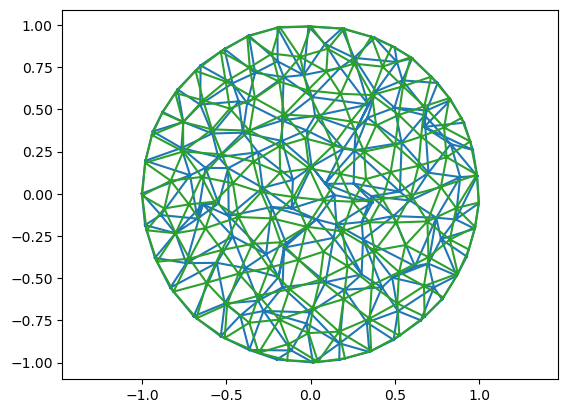

In [27]:
plt.triplot(noisy_v[:, 0], noisy_v[:, 1], hemesh.faces)
plt.triplot(smoothed_v[:, 0], smoothed_v[:, 1], hemesh.faces)
plt.axis('equal')

In [24]:
# Test 3D tangential smoothing on a sphere
mesh_3d = TriMesh.read_obj("../test_meshes/sphere.obj", dim=3)
hemesh_3d = msh.HeMesh.from_triangles(mesh_3d.vertices.shape[0], mesh_3d.faces)
verts_3d = mesh_3d.vertices

key = jax.random.PRNGKey(1)
noise_3d = 0.1 * jax.random.normal(key, shape=verts_3d.shape)
noisy_3d = verts_3d + noise_3d

print("Before 3D smoothing:")
print(get_mesh_quality_stats(noisy_3d, hemesh_3d))

smoothed_3d = noisy_3d
for _ in range(5):
    smoothed_3d = smooth_vertices_laplacian(smoothed_3d, hemesh_3d, step_size=0.3, bc='free')

print("\nAfter 5 Laplacian smoothing steps (3D):")
print(get_mesh_quality_stats(smoothed_3d, hemesh_3d))

  o Icosphere


Before 3D smoothing:
{'areas_min': 0.05567, 'areas_max': 0.31956, 'areas_cv': 0.35048, 'max_angle': 120.09799, 'min_angle': 19.84483, 'angles_std': 17.23441, 'n_degenerate': 0, 'n_total_faces': 80}

After 5 Laplacian smoothing steps (3D):
{'areas_min': 0.10323, 'areas_max': 0.20764, 'areas_cv': 0.13673, 'max_angle': 79.5562, 'min_angle': 45.60472, 'angles_std': 7.12533, 'n_degenerate': 0, 'n_total_faces': 80}


In [25]:
p = meshplot.plot(noisy_3d, hemesh_3d.faces, shading={"wireframe":True}, return_plot=True)

p.add_mesh(smoothed_3d + np.array([3, 0, 0]), hemesh_3d.faces, shading={"wireframe":True})

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.023059…

1